In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import pyplot as plt

import numpy as np

from aquacrop_slovenia.reading_data import get_climate
from aquacrop_slovenia.yield_projections import run_model_projection

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
result = run_model_projection("rakican", "model4", "rcp26")

Setting up working directory at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing3
Running AquaCrop simulation with project file: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing3\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing3\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [4]:
result

,Year1,Y(dry)
0,1981,9.682
1,1982,10.994
2,1983,8.013
3,1984,9.248
4,1985,10.367
...,...,...
114,2095,8.797
115,2096,10.799
116,2097,0.739
117,2098,11.960


<Axes: xlabel='Year1'>

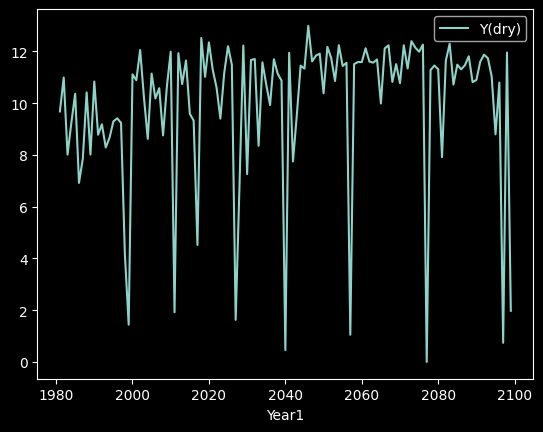

In [10]:
result.plot(x="Year1", y="Y(dry)", kind="line")

## 30-year period statistics

In [11]:
import pandas as pd

periods = {
    "1981-2010": (1981, 2010),
    "2011–2040": (2011, 2040),
    "2041–2070": (2041, 2070),
    "2071–2100": (2071, 2100),
}

rows = []
for label, (start, end) in periods.items():
    s = result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"]
    rows.append({
        "Period": label,
        "Mean": s.mean(),
        "Std": s.std(),
        "Min": s.min(),
        "Median": s.median(),
        "Max": s.max(),
    })

stats_df = pd.DataFrame(rows).set_index("Period").round(3)
stats_df

,Mean,Std,Min,Median,Max
Period,,,,,
1981-2010,9.236,2.185,1.438,9.358,12.058
2011–2040,9.593,3.331,0.459,10.948,12.523
2041–2070,11.033,2.123,1.051,11.579,12.988
2071–2100,10.254,3.380,0.000,11.458,12.399


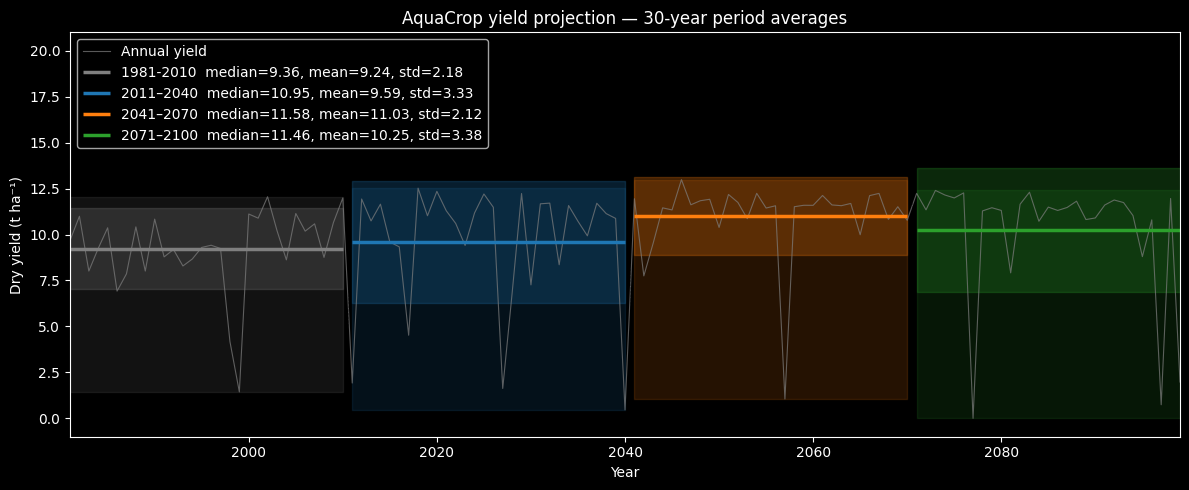

In [12]:
colors = ["tab:gray", "tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(result["Year1"], result["Y(dry)"], color="gray", linewidth=0.8, alpha=0.7, label="Annual yield")

for (label, (start, end)), color in zip(periods.items(), colors):
    s = result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"]
    mean, std, median = s.mean(), s.std(), s.median()
    ax.hlines(mean, start, end, color=color, linewidth=2.5, label=f"{label}  median={median:.2f}, mean={mean:.2f}, std={std:.2f}")
    ax.fill_between(range(start, end + 1), s.min(), s.max(), color=color, alpha=0.15, label="_")
    ax.fill_between(range(start, end + 1), mean - std, mean + std, color=color, alpha=0.25, label="_")
    ax.vlines(start - 0.5, 0, 20, color="black", linewidth=0.5, linestyle="--", alpha=0.4)

ax.set_xlabel("Year")
ax.set_ylabel("Dry yield (t ha⁻¹)")
ax.set_title("AquaCrop yield projection — 30-year period averages")
ax.legend(loc="upper left")
ax.set_xlim(result["Year1"].min(), result["Year1"].max())
fig.tight_layout()
plt.show()

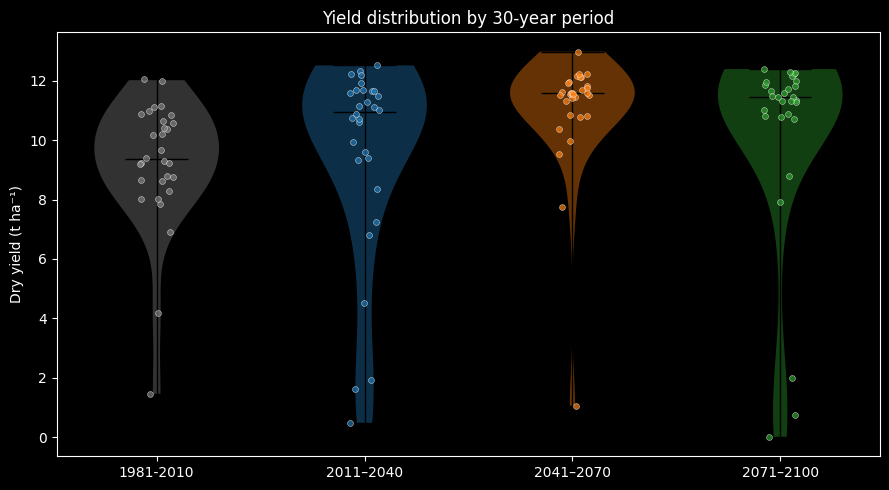

In [13]:
period_labels = list(periods.keys())
period_data = [
    result.loc[(result["Year1"] >= start) & (result["Year1"] <= end), "Y(dry)"].values
    for _, (start, end) in periods.items()
]
colors = ["tab:gray", "tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(9, 5))

parts = ax.violinplot(period_data, positions=range(len(period_labels)), widths=0.6, showmedians=True)
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.4)
for key in ("cmedians", "cbars", "cmins", "cmaxes"):
    parts[key].set_color("black")
    parts[key].set_linewidth(1)

rng = np.random.default_rng(0)
for i, (data, color) in enumerate(zip(period_data, colors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(i + jitter, data, color=color, s=18, alpha=0.7, zorder=3, edgecolors="white", linewidths=0.4)

ax.set_xticks(range(len(period_labels)))
ax.set_xticklabels(period_labels)
ax.set_ylabel("Dry yield (t ha⁻¹)")
ax.set_title("Yield distribution by 30-year period")
fig.tight_layout()
plt.show()